In [19]:
# =============================================
# 1. 필요한 라이브러리 가져오기
# =============================================

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pylab as plt
import numpy as np
import pandas as pd

# 그래프 한글 폰트 설정
from matplotlib import font_manager, rc
plt.rcParams['font.family'] = 'Malgun Gothic'          # 한글 폰트 지정
plt.rcParams['axes.unicode_minus'] = False             # 마이너스 부호 깨짐 방지

In [20]:
# =============================================
# 2. CIFAR-10 데이터 불러오기
# =============================================
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
# CIFAR-10 이미지는 32X32 크기의 컬러 이미지이고, 10개 클래스로 구성
# y 데이터(배치,1) 형태이기때문 reshape 필요

y_train = y_train.reshape(-1)     # shape (30000, 1) --> (30000)   
y_test = y_test.reshape(-1)       # shape (10000, 1) --> (10000)   

In [21]:
# =============================================
# 3. 데이터 정규화
# =============================================
x_train = x_train / 255.0                # RGB 값(0~255) -> 0~1 범위로 정규화
x_test = x_test / 255.0

In [22]:
# =============================================
# 4. 시각화를 위한 클래스 이름 정의
# =============================================
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

In [23]:
# =============================================
# 5. 데이터 증강(Data Augmentation) 정의
# =============================================
# data_augmentation = tf.keras.Sequential([
#     layers.RandomFlip("horizontal"),   # 이미지 좌우 랜덤하게 뒤집기 
#     layers.RandomRotation(0.05),       # 랜덤하게 회전 적용.  0.1 → 0.05 줄이기
#     layers.RandomZoom(0.1),            # 랜덤하게 확대/축소
#     layers.RandomContrast(0.1)         # 명암 효과  (밝은 것은 더 밝게, 어두운 것은 어둡게하여 선명도 개선)
# ])

In [32]:
# =============================================
# 6. CNN + Dropout 모델 구성
# =============================================
model = models.Sequential([
    #data_augmentation,

    # 첫 번째 CNN layer
    layers.Conv2D(32, (3,3), padding='same'),   # 컬러 이미지 입력
    layers.BatchNormalization(),                # 특징 추출해서 크기를 감소
    layers.Activation('relu'),
    layers.MaxPooling2D(2,2), 
    layers.Dropout(0.5),

    # 두 번째 CNN layer
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.5),

    # 세 번째 CNN layer
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2,2),

    # Fully Connected layer 
    layers.Flatten(),                               # 2D --> 1D 벡터로 변환
    layers.Dense(256),                              # 256개의 뉴런으로 학습
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),
    
    # 출력층
    layers.Dense(10, activation='softmax')          # 10개 클래스에 대한 확률 출력
])




In [33]:
# =============================================
# 7. 모델 컴파일
# =============================================
model.compile(
    optimizer='adam',                                
    loss='sparse_categorical_crossentropy',          
    metrics=['accuracy']                             
)

In [34]:
# =============================================
# 8. 모델 학습
# =============================================
history = model.fit(
    x_train, y_train,                                
    epochs=15,                                       
    batch_size=64,                                   
    validation_split=0.2,                            
    verbose=1                                        
)


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 62ms/step - accuracy: 0.5318 - loss: 1.3446 - val_accuracy: 0.6026 - val_loss: 1.1095
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.6709 - loss: 0.9378 - val_accuracy: 0.6718 - val_loss: 0.9534
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.7220 - loss: 0.7939 - val_accuracy: 0.7065 - val_loss: 0.8291
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 63ms/step - accuracy: 0.7563 - loss: 0.6967 - val_accuracy: 0.7092 - val_loss: 0.8211
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.7846 - loss: 0.6129 - val_accuracy: 0.7245 - val_loss: 0.7968
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 62ms/step - accuracy: 0.8073 - loss: 0.5492 - val_accuracy: 0.7101 - val_loss: 0.8726
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.8316 - loss: 0.4794 - val_accuracy: 0.7276 - val_loss: 0.8097
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 72ms/step - accuracy: 0.8525 - loss: 0.4259 - 

In [35]:
# =============================================
# 9. 테스트 데이터 평가
# =============================================
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"CIFAR-10 테스트 정확도: {test_acc:.4f}")
print(f"CIFAR-10 테스트 손실값: {test_loss:.4f}")

CIFAR-10 테스트 정확도: 0.7092
CIFAR-10 테스트 손실값: 0.9541


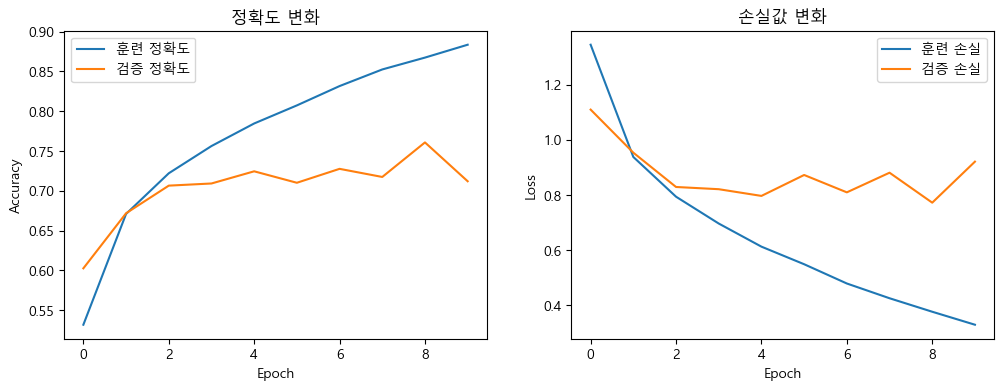

In [39]:
# =============================================
# 10. 학습 곡선(정확도/손실) 시각화
# =============================================
plt.figure(figsize=(12,4))

# ---- 정확도 그래프 ----
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='훈련 정확도')
plt.plot(history.history['val_accuracy'], label='검증 정확도')
plt.title("정확도 변화")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# ---- 손실 그래프 ----
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='훈련 손실')
plt.plot(history.history['val_loss'], label='검증 손실')
plt.title("손실값 변화")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [37]:
# =============================================
# 11. 예측 수행
# =============================================
predictions = model.predict(x_test)                        # 테스트 이미지 전체에 대한 예측 확률
pred_labels = np.argmax(predictions, axis=1)               # 가장 높은 확률의 클래스 선택

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


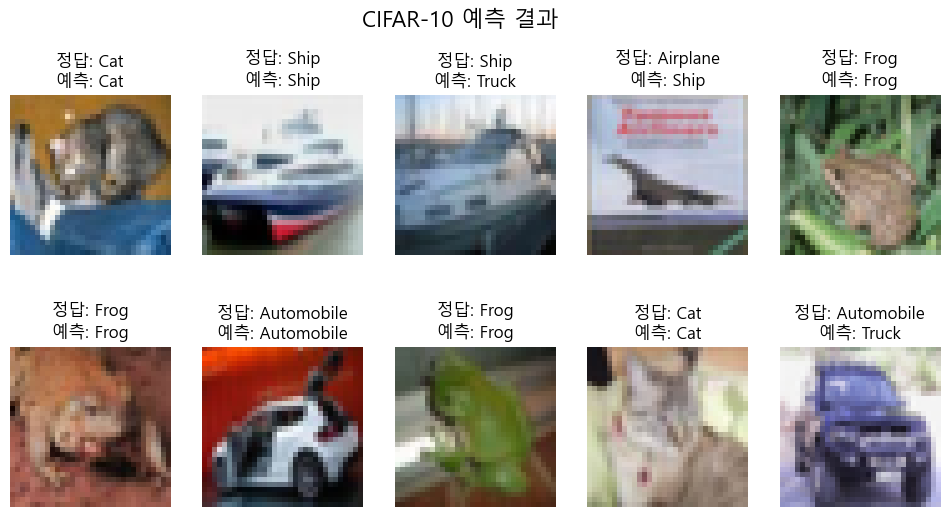

In [38]:
# =============================================
# 12. 앞 10개 이미지 예측 시각화
# =============================================
plt.figure(figsize=(12,6))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i])                               
    plt.title(f"정답: {class_names[y_test[i]]}\n예측: {class_names[pred_labels[i]]}")
    plt.axis("off")
plt.suptitle("CIFAR-10 예측 결과", fontsize=16)
plt.show()


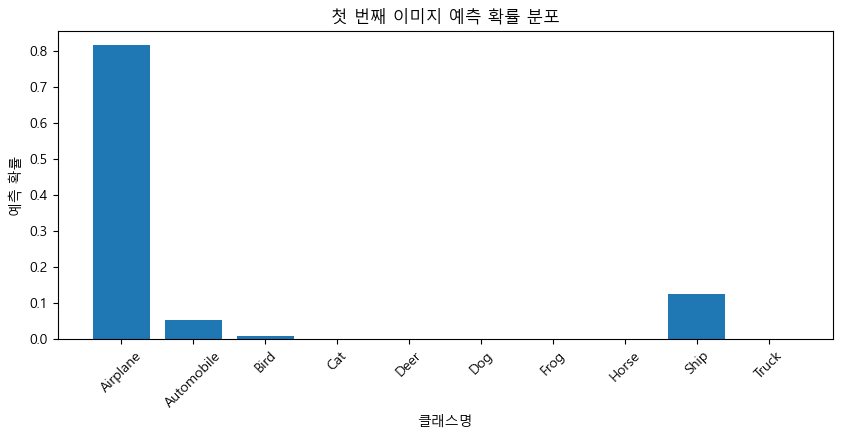

In [31]:
# =============================================
# 13. 첫 번째 이미지의 클래스별 예측 확률 시각화
# =============================================
plt.figure(figsize=(10,4))
plt.bar(range(10), predictions[3])
plt.xticks(range(10), class_names, rotation=45)
plt.xlabel("클래스명")
plt.ylabel("예측 확률")
plt.title("첫 번째 이미지 예측 확률 분포")
plt.show()